# Architecture Understanding — Visualizing What GNNs Learn on QM9

This notebook produces report-ready figures that reveal **how** each GNN
architecture (GCN, GAT, GATv2, SchNet) processes molecular graphs differently.

**Requires:** Trained checkpoints for GCN, GAT, GATv2, and SchNet in
`outputs/checkpoints/`. Run `train_colab.ipynb` first.

We include both **GAT** and **GATv2** because GATv2 incorporates bond-type
edge attributes into its attention scores (via `edge_dim`), while standard GAT
computes attention from node features alone. Comparing them isolates the effect
of edge-aware attention on learned representations.

**Figures produced:**
1. t-SNE of learned graph embeddings (4 panels)
2. GAT vs GATv2 attention weight comparison on the same molecules (2x4 grid)
3. Layer-wise embedding similarity (over-smoothing diagnostic: GCN vs GAT vs GATv2)
4. Prediction error vs molecule size (4 panels)
5. Predicted vs true scatter plots (4 panels)
6. SchNet 3D interaction visualization on example molecules
7. All-models training curve comparison

In [ ]:
# ── Cell 1: Setup ────────────────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

import os, sys
DRIVE_ROOT  = '/content/drive/MyDrive/gnn_qm9'
PROJECT_DIR = '/content/gnn_qm9'
REPO_URL    = 'https://github.com/amanikonda123/DL-Final-Project.git'

os.makedirs(f'{DRIVE_ROOT}/outputs/plots/analysis', exist_ok=True)

if os.path.exists(PROJECT_DIR):
    !git -C {PROJECT_DIR} pull
else:
    !git clone {REPO_URL} {PROJECT_DIR}

os.chdir(PROJECT_DIR)
if PROJECT_DIR not in sys.path:
    sys.path.insert(0, PROJECT_DIR)

import torch
TORCH_VER = torch.__version__.split('+')[0]
CUDA_VER  = 'cu121' if torch.cuda.is_available() else 'cpu'
!pip install -q torch-geometric
!pip install -q pyg-lib torch-scatter torch-sparse \
    -f https://data.pyg.org/whl/torch-{TORCH_VER}+{CUDA_VER}.html
!pip install -q pyyaml tqdm scikit-learn

import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from sklearn.manifold import TSNE

DEVICE     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DATA_ROOT  = f'{DRIVE_ROOT}/data/qm9_raw'
OUTPUT_DIR = f'{DRIVE_ROOT}/outputs'
PLOT_DIR   = f'{OUTPUT_DIR}/plots/analysis'
print(f'Device: {DEVICE}')

OSError: [Errno 30] Read-only file system: '/content'

In [ ]:
# ── Cell 2: Load Trained Models and Data ─────────────────────────────────────
from data.loader import get_dataloaders
from data.features import select_features, get_feature_dims
from models import build_model

# Load configs
with open("config/gcn.yaml") as f: gcn_cfg = yaml.safe_load(f)
with open("config/gat.yaml") as f: gat_cfg = yaml.safe_load(f)
with open("config/gatv2.yaml") as f: gatv2_cfg = yaml.safe_load(f)
with open("config/schnet.yaml") as f: schnet_cfg = yaml.safe_load(f)

# Load data
topo_train, topo_val, topo_test, topo_norm = get_dataloaders(gcn_cfg, root=DATA_ROOT)
geo_train, geo_val, geo_test, geo_norm = get_dataloaders(schnet_cfg, root=DATA_ROOT)

# Build and load models
def load_model(name, cfg, ckpt_path):
    feature_dims = get_feature_dims(cfg["dataset"].get("feature_mode", "topology"))
    model = build_model(name, cfg, feature_dims).to(DEVICE)
    model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE, weights_only=True))
    model.eval()
    param_count = sum(p.numel() for p in model.parameters())
    print(f"  {name.upper()}: loaded ({param_count:,} params)")
    return model

print("Loading checkpoints...")
gcn_model    = load_model("gcn",    gcn_cfg,    f"{OUTPUT_DIR}/checkpoints/gcn_best.pt")
gat_model    = load_model("gat",    gat_cfg,    f"{OUTPUT_DIR}/checkpoints/gat_best.pt")
gatv2_model  = load_model("gatv2",  gatv2_cfg,  f"{OUTPUT_DIR}/checkpoints/gatv2_best.pt")
schnet_model = load_model("schnet", schnet_cfg, f"{OUTPUT_DIR}/checkpoints/schnet_best.pt")
print("All models loaded.")

## Figure 1: t-SNE of Learned Graph Embeddings

Extract the graph-level embedding (before the regression head) from each model
on ~5000 test molecules. Run t-SNE and color by the true property value.

This reveals how each architecture organizes molecular space. SchNet should
show smoother property gradients since it uses 3D atomic coordinates.

In [ ]:
# ── Cell 3: t-SNE of Graph Embeddings ────────────────────────────────────────
N_SAMPLES = 5000

def collect_embeddings(model, loader, normalizer, model_name, feature_mode, n=N_SAMPLES):
    """Extract graph-level embeddings and true targets for n test molecules."""
    embeddings, targets = [], []
    count = 0
    with torch.no_grad():
        for batch in loader:
            batch = select_features(batch, feature_mode)
            batch = batch.to(DEVICE)
            if model_name == "schnet":
                emb, _ = model.get_embedding(batch.z, batch.pos, batch.batch)
            elif model_name == "gatv2":
                emb, _ = model.get_embedding(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
            else:
                emb, _ = model.get_embedding(batch.x, batch.edge_index, batch.batch)
            embeddings.append(emb.cpu())
            targets.append(normalizer.denormalize(batch.y.cpu()))
            count += batch.num_graphs
            if count >= n:
                break
    return torch.cat(embeddings)[:n].numpy(), torch.cat(targets)[:n].numpy()

print("Extracting embeddings...")
gcn_emb,    gcn_tgt    = collect_embeddings(gcn_model,    topo_test, topo_norm, "gcn",    "topology")
gat_emb,    gat_tgt    = collect_embeddings(gat_model,    topo_test, topo_norm, "gat",    "topology")
gatv2_emb,  gatv2_tgt  = collect_embeddings(gatv2_model,  topo_test, topo_norm, "gatv2",  "topology")
schnet_emb, schnet_tgt = collect_embeddings(schnet_model, geo_test,  geo_norm,  "schnet", "geometry")

print("Running t-SNE (4 fits — this may take a few minutes)...")
gcn_tsne    = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(gcn_emb)
gat_tsne    = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(gat_emb)
gatv2_tsne  = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(gatv2_emb)
schnet_tsne = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(schnet_emb)

# 4 plot panels + 1 narrow colorbar axis via GridSpec
fig = plt.figure(figsize=(22, 5))
gs = GridSpec(1, 5, width_ratios=[1, 1, 1, 1, 0.05], wspace=0.08)
axes = [fig.add_subplot(gs[0, i]) for i in range(4)]
cax = fig.add_subplot(gs[0, 4])

fig.suptitle("t-SNE of Learned Graph Embeddings — Colored by True U0 (Ha)", fontsize=14, y=1.02)

for ax, tsne, tgt, title in [
    (axes[0], gcn_tsne,    gcn_tgt,    "GCN"),
    (axes[1], gat_tsne,    gat_tgt,    "GAT"),
    (axes[2], gatv2_tsne,  gatv2_tgt,  "GATv2"),
    (axes[3], schnet_tsne, schnet_tgt, "SchNet"),
]:
    sc = ax.scatter(tsne[:, 0], tsne[:, 1], c=tgt.ravel(), cmap="viridis",
                    s=4, alpha=0.6, rasterized=True)
    ax.set_title(title, fontsize=13)
    ax.set_xticks([])
    ax.set_yticks([])

fig.colorbar(sc, cax=cax, label="True U0 (Ha)")
plt.savefig(f"{PLOT_DIR}/tsne_embeddings.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved to {PLOT_DIR}/tsne_embeddings.png")

## Figure 2: Attention Weight Visualization — GAT vs GATv2

Extract attention coefficients from the last layer of both GAT and GATv2 on
the same four molecules (varying sizes). Edge thickness = attention weight.

GAT computes attention from node features only, while GATv2 incorporates
bond-type edge attributes into its attention scores. Comparing them on
identical molecules reveals how edge awareness changes which bonds the
model focuses on.

In [ ]:
# ── Cell 4: GAT vs GATv2 Attention Visualization ────────────────────────────
import networkx as nx
from torch_geometric.utils import subgraph

ATOM_LABELS = {1: "H", 6: "C", 7: "N", 8: "O", 9: "F"}

# Extract individual molecules from the test loader (keep edge_attr for GATv2)
test_mols = []
for batch in topo_test:
    for i in range(batch.num_graphs):
        mask = batch.batch == i
        node_idx = mask.nonzero(as_tuple=True)[0]
        mol_data = batch.__class__()
        mol_data.x = batch.x[mask]
        mol_data.z = batch.z[mask]
        ei, _, edge_mask = subgraph(mask, batch.edge_index, relabel_nodes=True, return_edge_mask=True)
        mol_data.edge_index = ei
        mol_data.edge_attr = batch.edge_attr[edge_mask] if batch.edge_attr is not None else None
        mol_data.y = batch.y[i:i+1]
        mol_data.batch = torch.zeros(mask.sum().item(), dtype=torch.long)
        test_mols.append(mol_data)
        if len(test_mols) >= 200:
            break
    if len(test_mols) >= 200:
        break

# Select 4 molecules of varying sizes
sizes = [m.x.size(0) for m in test_mols]
idx_small  = min(range(len(sizes)), key=lambda i: abs(sizes[i] - 5))
idx_medium = min(range(len(sizes)), key=lambda i: abs(sizes[i] - 12))
idx_large  = min(range(len(sizes)), key=lambda i: abs(sizes[i] - 18))
idx_xl     = min(range(len(sizes)), key=lambda i: abs(sizes[i] - 25))
selected = [test_mols[i] for i in [idx_small, idx_medium, idx_large, idx_xl]]

def draw_attention(ax, mol, ei, alpha_mean, title_prefix):
    """Draw a molecule graph with edge thickness proportional to attention."""
    G = nx.Graph()
    n_nodes = mol.x.size(0)
    for n in range(n_nodes):
        G.add_node(n)

    ei_cpu = ei.cpu().numpy()
    edge_weights = {}
    for e in range(ei_cpu.shape[1]):
        src, dst = int(ei_cpu[0, e]), int(ei_cpu[1, e])
        if src < dst:
            key = (src, dst)
            edge_weights[key] = edge_weights.get(key, 0) + alpha_mean[e]
    for (u, v), w in edge_weights.items():
        G.add_edge(u, v, weight=w)

    pos = nx.spring_layout(G, seed=42)
    labels = {n: ATOM_LABELS.get(mol.z[n].item(), "?") for n in range(n_nodes)}
    weights = [G[u][v]["weight"] for u, v in G.edges()]
    max_w = max(weights) if weights else 1
    widths = [3.0 * w / max_w + 0.5 for w in weights]

    nx.draw_networkx_nodes(G, pos, ax=ax, node_size=300, node_color="lightblue", edgecolors="black")
    nx.draw_networkx_edges(G, pos, ax=ax, width=widths, alpha=0.7, edge_color="steelblue")
    nx.draw_networkx_labels(G, pos, labels, ax=ax, font_size=8)
    ax.set_title(f"{title_prefix} — {n_nodes} atoms", fontsize=10)
    ax.axis("off")

# 2 rows (GAT top, GATv2 bottom) x 4 columns (one per molecule)
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle("Attention Weights — Last Layer (edge thickness = attention)\nTop: GAT (node-only)  |  Bottom: GATv2 (edge-aware)",
             fontsize=14, y=1.02)

for col, mol in enumerate(selected):
    mol_dev = mol.to(DEVICE)
    mol_feat = select_features(mol_dev, "topology")

    # GAT (top row)
    gat_attn = gat_model.get_attention_weights(mol_feat.x, mol_feat.edge_index, mol_feat.batch)
    ei_gat, alpha_gat = gat_attn[-1]
    draw_attention(axes[0, col], mol, ei_gat, alpha_gat.mean(dim=-1).cpu().numpy(), "GAT")

    # GATv2 (bottom row)
    gatv2_attn = gatv2_model.get_attention_weights(
        mol_feat.x, mol_feat.edge_index, mol_feat.edge_attr, mol_feat.batch)
    ei_v2, alpha_v2 = gatv2_attn[-1]
    draw_attention(axes[1, col], mol, ei_v2, alpha_v2.mean(dim=-1).cpu().numpy(), "GATv2")

plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/gat_attention.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved to {PLOT_DIR}/gat_attention.png")

## Figure 3: Layer-wise Embedding Similarity (Over-smoothing)

Compute the mean pairwise cosine similarity of node embeddings after each GNN layer.
If similarity approaches 1.0, all nodes become indistinguishable (over-smoothing).
GAT's attention should resist this better than GCN's uniform aggregation.

In [ ]:
# ── Cell 5: Over-smoothing Diagnostic ────────────────────────────────────────
from torch.nn.functional import cosine_similarity

def compute_layer_similarity(model, loader, model_name, feature_mode, n_batches=10):
    """Compute mean pairwise cosine similarity per layer."""
    layer_sims = None
    count = 0

    with torch.no_grad():
        for batch in loader:
            batch = select_features(batch, feature_mode)
            batch = batch.to(DEVICE)
            if model_name == "schnet":
                break
            elif model_name == "gatv2":
                _, layer_embeds = model.get_embedding(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
            else:
                _, layer_embeds = model.get_embedding(batch.x, batch.edge_index, batch.batch)

            if layer_sims is None:
                layer_sims = [0.0] * len(layer_embeds)

            for li, emb in enumerate(layer_embeds):
                emb_norm = emb / (emb.norm(dim=1, keepdim=True) + 1e-8)
                sim_matrix = emb_norm @ emb_norm.T
                n = emb_norm.size(0)
                mask = ~torch.eye(n, dtype=torch.bool, device=sim_matrix.device)
                mean_sim = sim_matrix[mask].mean().item()
                layer_sims[li] += mean_sim

            count += 1
            if count >= n_batches:
                break

    return [s / count for s in layer_sims] if layer_sims else []

print("Computing layer-wise similarity...")
gcn_sims   = compute_layer_similarity(gcn_model,   topo_test, "gcn",   "topology")
gat_sims   = compute_layer_similarity(gat_model,   topo_test, "gat",   "topology")
gatv2_sims = compute_layer_similarity(gatv2_model, topo_test, "gatv2", "topology")

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(range(len(gcn_sims)),   gcn_sims,   "o-", label="GCN",   linewidth=2, markersize=7)
ax.plot(range(len(gat_sims)),   gat_sims,   "s-", label="GAT",   linewidth=2, markersize=7)
ax.plot(range(len(gatv2_sims)), gatv2_sims, "D-", label="GATv2", linewidth=2, markersize=7)
ax.axhline(y=1.0, color="red", linestyle="--", alpha=0.5, label="Perfect similarity")
ax.set_xlabel("Layer Index", fontsize=12)
ax.set_ylabel("Mean Pairwise Cosine Similarity", fontsize=12)
ax.set_title("Over-smoothing Diagnostic — Node Embedding Similarity per Layer", fontsize=13)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/oversmoothing.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved to {PLOT_DIR}/oversmoothing.png")

## Figure 4: Prediction Error vs Molecule Size

Are larger molecules harder to predict? Topology-based models may struggle more
with bigger molecules because they miss geometric interactions, while SchNet
should maintain accuracy regardless of size.

In [ ]:
# ── Cell 6: Error vs Molecule Size ───────────────────────────────────────────
from utils.metrics import mae as compute_mae

def collect_errors_by_size(model, loader, normalizer, model_name, feature_mode):
    """Collect (num_atoms, abs_error) for each test molecule."""
    sizes, errors = [], []
    with torch.no_grad():
        for batch in loader:
            batch_proc = select_features(batch, feature_mode)
            batch_proc = batch_proc.to(DEVICE)

            if model_name == "schnet":
                pred = model(batch_proc.z, batch_proc.pos, batch_proc.batch)
            elif model_name == "gatv2":
                pred = model(batch_proc.x, batch_proc.edge_index, batch_proc.edge_attr, batch_proc.batch)
            else:
                pred = model(batch_proc.x, batch_proc.edge_index, batch_proc.batch)

            pred_de = normalizer.denormalize(pred.cpu())
            tgt_de  = normalizer.denormalize(batch_proc.y.cpu())

            for i in range(batch.num_graphs):
                n_atoms = (batch.batch == i).sum().item()
                err = abs(pred_de[i].item() - tgt_de[i].item())
                sizes.append(n_atoms)
                errors.append(err)
    return np.array(sizes), np.array(errors)

print("Collecting prediction errors by molecule size...")
gcn_sizes,    gcn_errors    = collect_errors_by_size(gcn_model,    topo_test, topo_norm, "gcn",    "topology")
gat_sizes,    gat_errors    = collect_errors_by_size(gat_model,    topo_test, topo_norm, "gat",    "topology")
gatv2_sizes,  gatv2_errors  = collect_errors_by_size(gatv2_model,  topo_test, topo_norm, "gatv2",  "topology")
schnet_sizes, schnet_errors = collect_errors_by_size(schnet_model, geo_test,  geo_norm,  "schnet", "geometry")

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
fig.suptitle("Prediction Error vs Molecule Size (Number of Atoms)", fontsize=14, y=1.02)

for ax, sizes, errors, title in [
    (axes[0], gcn_sizes,    gcn_errors,    "GCN"),
    (axes[1], gat_sizes,    gat_errors,    "GAT"),
    (axes[2], gatv2_sizes,  gatv2_errors,  "GATv2"),
    (axes[3], schnet_sizes, schnet_errors, "SchNet"),
]:
    ax.scatter(sizes, errors, s=3, alpha=0.3, rasterized=True)
    unique_sizes = sorted(set(sizes))
    bin_means = [np.mean(errors[sizes == s]) for s in unique_sizes]
    ax.plot(unique_sizes, bin_means, "r-", linewidth=2, label="Mean error")
    ax.set_xlabel("Number of Atoms", fontsize=11)
    ax.set_ylabel("Absolute Error (Ha)", fontsize=11)
    ax.set_title(title, fontsize=13)
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/error_vs_size.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved to {PLOT_DIR}/error_vs_size.png")

## Figure 5: Predicted vs True Property Values

Points on the diagonal indicate perfect predictions. Systematic deviations
reveal where each model struggles.

In [ ]:
# ── Cell 7: Predicted vs True ────────────────────────────────────────────────
def collect_predictions(model, loader, normalizer, model_name, feature_mode):
    """Collect (predicted, true) for all test molecules."""
    preds, targets = [], []
    with torch.no_grad():
        for batch in loader:
            batch = select_features(batch, feature_mode)
            batch = batch.to(DEVICE)
            if model_name == "schnet":
                pred = model(batch.z, batch.pos, batch.batch)
            elif model_name == "gatv2":
                pred = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
            else:
                pred = model(batch.x, batch.edge_index, batch.batch)
            preds.append(normalizer.denormalize(pred.cpu()))
            targets.append(normalizer.denormalize(batch.y.cpu()))
    return torch.cat(preds).numpy(), torch.cat(targets).numpy()

print("Collecting predictions...")
gcn_pred,    gcn_true    = collect_predictions(gcn_model,    topo_test, topo_norm, "gcn",    "topology")
gat_pred,    gat_true    = collect_predictions(gat_model,    topo_test, topo_norm, "gat",    "topology")
gatv2_pred,  gatv2_true  = collect_predictions(gatv2_model,  topo_test, topo_norm, "gatv2",  "topology")
schnet_pred, schnet_true = collect_predictions(schnet_model, geo_test,  geo_norm,  "schnet", "geometry")

# Compute a shared color range (95th percentile of errors across all models)
all_errors = np.concatenate([
    np.abs(gcn_pred.ravel()    - gcn_true.ravel()),
    np.abs(gat_pred.ravel()    - gat_true.ravel()),
    np.abs(gatv2_pred.ravel()  - gatv2_true.ravel()),
    np.abs(schnet_pred.ravel() - schnet_true.ravel()),
])
vmax_clip = np.percentile(all_errors, 95)

# 4 plot panels + 1 narrow colorbar axis via GridSpec
fig = plt.figure(figsize=(22, 5))
gs = GridSpec(1, 5, width_ratios=[1, 1, 1, 1, 0.05], wspace=0.08)
axes = [fig.add_subplot(gs[0, i]) for i in range(4)]
cax = fig.add_subplot(gs[0, 4])

fig.suptitle("Predicted vs True U0 — Test Set", fontsize=14, y=1.02)

for ax, pred, true, title in [
    (axes[0], gcn_pred,    gcn_true,    "GCN"),
    (axes[1], gat_pred,    gat_true,    "GAT"),
    (axes[2], gatv2_pred,  gatv2_true,  "GATv2"),
    (axes[3], schnet_pred, schnet_true, "SchNet"),
]:
    err = np.abs(pred.ravel() - true.ravel())
    sc = ax.scatter(true.ravel(), pred.ravel(), c=err, cmap="coolwarm",
                    vmin=0, vmax=vmax_clip, s=3, alpha=0.5, rasterized=True)
    lims = [min(true.min(), pred.min()), max(true.max(), pred.max())]
    ax.plot(lims, lims, "k--", linewidth=1, alpha=0.5)
    ax.set_xlabel("True U0 (Ha)", fontsize=11)
    ax.set_ylabel("Predicted U0 (Ha)", fontsize=11)
    ax.set_title(f"{title}  |  MAE={np.mean(err):.2f}", fontsize=12)
    ax.grid(alpha=0.3)

fig.colorbar(sc, cax=cax, label="Absolute Error (Ha)")
plt.savefig(f"{PLOT_DIR}/predicted_vs_true.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved to {PLOT_DIR}/predicted_vs_true.png")

## Figure 6: SchNet 3D Interaction Visualization

Visualize a few QM9 molecules in their native 3D coordinates. Atom color and
size reflect the final SchNet atom-state magnitude, while edge thickness and
edge color reflect the strongest learned geometric interactions inside SchNet's
radius graph.

In [ ]:
# # ── Cell 8a: Standalone Setup for SchNet 3D Visualization ───────────────────
# # Run this cell first if you want to execute only the SchNet 3D section,
# # especially in a fresh local VS Code/Jupyter kernel.

# import os
# import sys
# import yaml
# import torch
# import numpy as np
# import matplotlib.pyplot as plt
# from matplotlib import cm, colors

# from data.loader import get_dataloaders
# from data.features import get_feature_dims
# from models import build_model

# PROJECT_DIR = os.getcwd()
# if PROJECT_DIR not in sys.path:
#     sys.path.insert(0, PROJECT_DIR)

# DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# DATA_ROOT = os.path.join(PROJECT_DIR, 'data', 'qm9_raw')
# OUTPUT_DIR = os.path.join(PROJECT_DIR, 'outputs')
# PLOT_DIR = os.path.join(OUTPUT_DIR, 'plots', 'analysis')
# os.makedirs(PLOT_DIR, exist_ok=True)

# with open('config/schnet.yaml') as f:
#     SCHNET_CFG = yaml.safe_load(f)

# _, _, geo_test, geo_norm = get_dataloaders(SCHNET_CFG, root=DATA_ROOT)
# feature_dims = get_feature_dims(SCHNET_CFG['dataset'].get('feature_mode', 'geometry'))
# schnet_model = build_model('schnet', SCHNET_CFG, feature_dims).to(DEVICE)
# ckpt_path = os.path.join(OUTPUT_DIR, 'checkpoints', 'schnet_best.pt')
# schnet_model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE, weights_only=True))
# schnet_model.eval()

# print('Standalone SchNet 3D setup ready')
# print('Device:', DEVICE)
# print('Checkpoint:', ckpt_path)
# print('Plot dir:', PLOT_DIR)


[loader] Target: U0 (Internal energy at 0K, Ha)
[loader] Loading QM9 from '/Users/Adiman17/Desktop/deep-learning/Final Project/DL-Final-Project/data/qm9_raw'...
[loader] Train target mean=-11183.0596, std=1081.5560
[loader] Split sizes — train: 104664, val: 13083, test: 13084
Standalone SchNet 3D setup ready
Device: cpu
Checkpoint: /Users/Adiman17/Desktop/deep-learning/Final Project/DL-Final-Project/outputs/checkpoints/schnet_best.pt
Plot dir: /Users/Adiman17/Desktop/deep-learning/Final Project/DL-Final-Project/outputs/plots/analysis


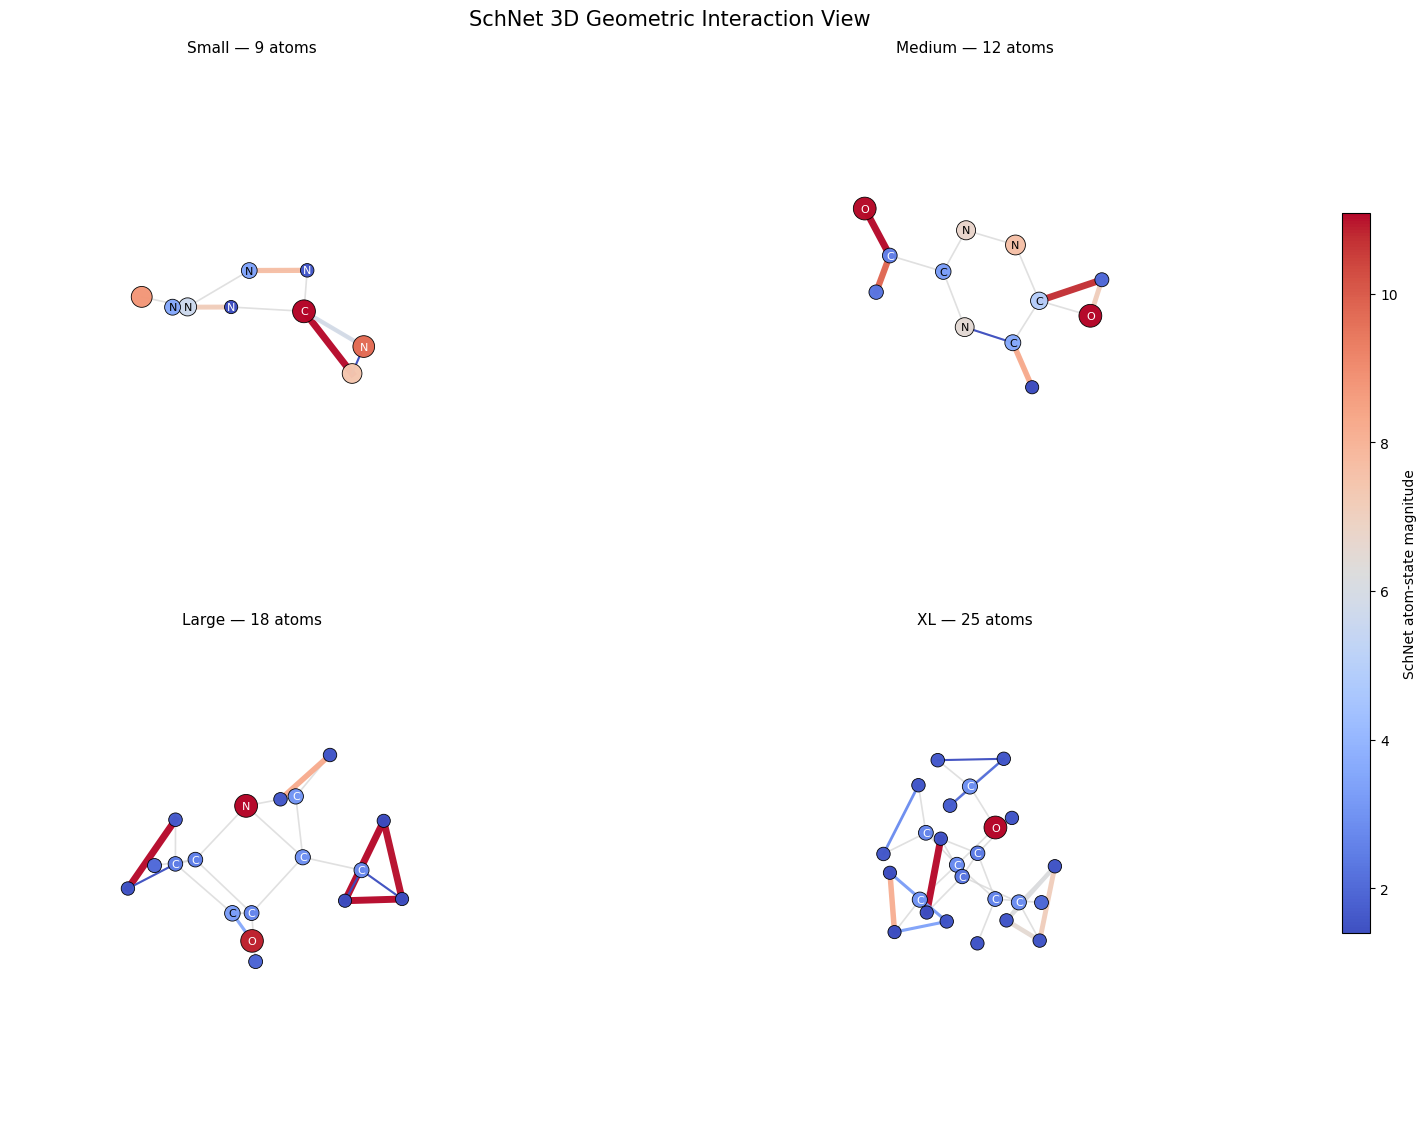

Saved to /Users/Adiman17/Desktop/deep-learning/Final Project/DL-Final-Project/outputs/plots/analysis/schnet_3d_interactions.png


In [ ]:
# ── Cell 8b: SchNet 3D Interaction Visualization ────────────────────────────
from collections import defaultdict
from matplotlib import cm, colors
from torch_geometric.utils import subgraph

with open('config/schnet.yaml') as f:
    SCHNET_CFG = yaml.safe_load(f)

_, _, geo_test, geo_norm = get_dataloaders(SCHNET_CFG, root=DATA_ROOT)
feature_dims = get_feature_dims(SCHNET_CFG['dataset'].get('feature_mode', 'geometry'))
schnet_model = build_model('schnet', SCHNET_CFG, feature_dims).to(DEVICE)
ckpt_path = os.path.join(OUTPUT_DIR, 'checkpoints', 'schnet_best.pt')
schnet_model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE, weights_only=True))
schnet_model.eval()

ATOM_LABELS = {1: 'H', 6: 'C', 7: 'N', 8: 'O', 9: 'F'}

geo_mols = []
for batch in geo_test:
    for i in range(batch.num_graphs):
        mask = batch.batch == i
        mol = batch.__class__()
        mol.z = batch.z[mask]
        mol.pos = batch.pos[mask]
        mol.y = batch.y[i:i+1]
        mol.batch = torch.zeros(mask.sum().item(), dtype=torch.long)
        ei, _ = subgraph(mask, batch.edge_index, relabel_nodes=True)
        mol.edge_index = ei
        geo_mols.append(mol)
        if len(geo_mols) >= 200:
            break
    if len(geo_mols) >= 200:
        break

sizes = [m.z.size(0) for m in geo_mols]
idx_small  = min(range(len(sizes)), key=lambda i: abs(sizes[i] - 5))
idx_medium = min(range(len(sizes)), key=lambda i: abs(sizes[i] - 12))
idx_large  = min(range(len(sizes)), key=lambda i: abs(sizes[i] - 18))
idx_xl     = min(range(len(sizes)), key=lambda i: abs(sizes[i] - 25))
selected_geo = [geo_mols[i] for i in [idx_small, idx_medium, idx_large, idx_xl]]

def summarize_interactions(edge_index, edge_weight, edge_strength):
    pair_scores = defaultdict(list)
    pair_dists = defaultdict(list)
    ei = edge_index.cpu().numpy()
    ew = edge_weight.cpu().numpy()
    es = edge_strength.cpu().numpy()

    for k in range(ei.shape[1]):
        src, dst = int(ei[0, k]), int(ei[1, k])
        if src == dst:
            continue
        key = tuple(sorted((src, dst)))
        pair_scores[key].append(float(es[k]))
        pair_dists[key].append(float(ew[k]))

    summary = []
    for key, vals in pair_scores.items():
        summary.append((key, float(np.mean(vals)), float(np.mean(pair_dists[key]))))
    summary.sort(key=lambda x: x[1], reverse=True)
    return summary

def unique_bonds(edge_index):
    bonds = set()
    ei = edge_index.cpu().numpy()
    for k in range(ei.shape[1]):
        src, dst = int(ei[0, k]), int(ei[1, k])
        if src != dst:
            bonds.add(tuple(sorted((src, dst))))
    return sorted(bonds)

def set_equal_3d_axes(ax, pos):
    mins = pos.min(axis=0)
    maxs = pos.max(axis=0)
    centers = (mins + maxs) / 2.0
    radius = max((maxs - mins).max() / 2.0, 1e-3)
    ax.set_xlim(centers[0] - radius, centers[0] + radius)
    ax.set_ylim(centers[1] - radius, centers[1] + radius)
    ax.set_zlim(centers[2] - radius, centers[2] + radius)
    ax.set_box_aspect((1, 1, 1))

def draw_schnet_3d(ax, mol, title):
    mol_dev = mol.to(DEVICE)
    info = schnet_model.get_interaction_graph(mol_dev.z, mol_dev.pos, mol_dev.batch)

    pos = info['pos'].cpu().numpy()
    atom_strength = info['atom_strength'].cpu().numpy()
    interactions = summarize_interactions(
        info['edge_index'], info['edge_weight'], info['edge_strength']
    )

    # Draw true molecular bonds faintly as scaffold.
    for u, v in unique_bonds(mol.edge_index):
        xyz = pos[[u, v]]
        ax.plot(xyz[:, 0], xyz[:, 1], xyz[:, 2], color='lightgray', linewidth=1.2, alpha=0.7, zorder=1)

    top_k = min(max(5, mol.z.size(0) // 2), 10, len(interactions))
    top_interactions = interactions[:top_k]

    if top_interactions:
        strengths = np.array([s for _, s, _ in top_interactions])
        norm_edges = colors.Normalize(vmin=strengths.min(), vmax=strengths.max() + 1e-8)
        edge_cmap = cm.coolwarm
        for (u, v), strength, dist in top_interactions:
            xyz = pos[[u, v]]
            color = edge_cmap(norm_edges(strength))
            width = 1.5 + 3.5 * norm_edges(strength)
            ax.plot(xyz[:, 0], xyz[:, 1], xyz[:, 2], color=color, linewidth=width, alpha=0.95, zorder=2)

    atom_norm = colors.Normalize(vmin=atom_strength.min(), vmax=atom_strength.max() + 1e-8)
    atom_cmap = cm.coolwarm
    atom_sizes = 90 + 180 * atom_norm(atom_strength)
    scatter = ax.scatter(
        pos[:, 0], pos[:, 1], pos[:, 2],
        c=atom_strength, cmap=atom_cmap, s=atom_sizes,
        edgecolors='black', linewidths=0.6, alpha=0.98, zorder=3,
    )

    for idx, (x, y, z) in enumerate(pos):
        atomic_num = int(mol.z[idx])
        if atomic_num != 1:  # label heavy atoms only
            rgba = atom_cmap(atom_norm(atom_strength[idx]))
            luminance = 0.2126 * rgba[0] + 0.7152 * rgba[1] + 0.0722 * rgba[2]
            text_color = 'black' if luminance > 0.6 else 'white'
            ax.text(x, y, z, ATOM_LABELS.get(atomic_num, '?'), fontsize=8,
                    ha='center', va='center', color=text_color, zorder=4)

    set_equal_3d_axes(ax, pos)
    ax.set_title(f'{title} — {mol.z.size(0)} atoms', fontsize=11, pad=12)
    ax.view_init(elev=22, azim=35)
    ax.set_axis_off()
    return scatter

fig = plt.figure(figsize=(16, 12))
axes = [fig.add_subplot(2, 2, i + 1, projection='3d') for i in range(4)]
fig.suptitle('SchNet 3D Geometric Interaction View', fontsize=15, y=0.97)

last_scatter = None
for ax, mol, title in zip(axes, selected_geo, ['Small', 'Medium', 'Large', 'XL']):
    last_scatter = draw_schnet_3d(ax, mol, title)

fig.subplots_adjust(left=0.03, right=0.9, top=0.92, bottom=0.04, wspace=0.08, hspace=0.18)
cax = fig.add_axes([0.92, 0.2, 0.018, 0.6])
cbar = fig.colorbar(last_scatter, cax=cax)
cbar.set_label('SchNet atom-state magnitude')

plt.savefig(f'{PLOT_DIR}/schnet_3d_interactions.png', dpi=160)
plt.show()
print(f'Saved to {PLOT_DIR}/schnet_3d_interactions.png')


In [ ]:
selected_geo = [selected_geo[0]]

def draw_schnet_3d(ax, mol, title):
    mol_dev = mol.to(DEVICE)
    info = schnet_model.get_interaction_graph(mol_dev.z, mol_dev.pos, mol_dev.batch)

    pos = info['pos'].cpu().numpy()
    atom_strength = info['atom_strength'].cpu().numpy()
    interactions = summarize_interactions(
        info['edge_index'], info['edge_weight'], info['edge_strength']
    )

    top_interactions = interactions[:8]

    if top_interactions:
        strengths = np.array([s for _, s, _ in top_interactions])
        norm_edges = colors.Normalize(vmin=strengths.min(), vmax=strengths.max() + 1e-8)
        edge_cmap = cm.plasma
        for (u, v), strength, dist in top_interactions:
            xyz = pos[[u, v]]
            color = edge_cmap(norm_edges(strength))
            width = 1.0 + 4.0 * norm_edges(strength)
            ax.plot(xyz[:, 0], xyz[:, 1], xyz[:, 2], color=color, linewidth=width, alpha=0.85)

    atom_norm = colors.Normalize(vmin=atom_strength.min(), vmax=atom_strength.max() + 1e-8)
    atom_sizes = 80 + 220 * atom_norm(atom_strength)
    scatter = ax.scatter(
        pos[:, 0], pos[:, 1], pos[:, 2],
        c=atom_strength, cmap='viridis', s=atom_sizes,
        edgecolors='black', linewidths=0.6, alpha=0.95,
    )

    ax.set_title(title)
    ax.set_axis_off()
    return scatter

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(1, 1, 1, projection='3d')
draw_schnet_3d(ax, selected_geo[0], 'SchNet 3D')
plt.show()


## Figure 7: All-Models Training Curve Comparison

Overlay training and validation curves for all models.
Shows relative convergence speed and final performance.

In [ ]:
# ── Cell 9: Training Curves Comparison ───────────────────────────────────────
import glob

history_files = glob.glob(f"{OUTPUT_DIR}/logs/*_history.csv")
histories = {}
for path in sorted(history_files):
    name = os.path.basename(path).replace("_history.csv", "")
    try:
        df = pd.read_csv(path)
        if len(df) > 0:
            histories[name] = df
            print(f"  {name}: {len(df)} epochs")
    except Exception:
        pass

if len(histories) == 0:
    print("No training histories found. Run train_colab.ipynb first.")
else:
    COLORS = {"gcn": "#4C72B0", "gat": "#DD8452", "gatv2": "#55A868", "schnet": "#C44E52"}

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle("Training Curves — All Models", fontsize=14)

    for name, df in histories.items():
        color = COLORS.get(name, "grey")
        axes[0].plot(df["epoch"], df["val_loss"], label=f"{name.upper()} val",
                     color=color, linewidth=2)
        axes[0].plot(df["epoch"], df["train_loss"], label=f"{name.upper()} train",
                     color=color, linewidth=1, linestyle="--", alpha=0.5)

        axes[1].plot(df["epoch"], df["val_mae"], label=name.upper(),
                     color=color, linewidth=2)

    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("MSE Loss (normalized)")
    axes[0].set_title("Train/Val Loss")
    axes[0].legend(fontsize=8, ncol=2)
    axes[0].grid(alpha=0.3)

    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Val MAE (Ha)")
    axes[1].set_title("Validation MAE")
    axes[1].legend(fontsize=10)
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(f"{PLOT_DIR}/training_curves_all.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved to {PLOT_DIR}/training_curves_all.png")

In [ ]:
# ── Cell 10: Summary ─────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("ALL FIGURES GENERATED")
print("=" * 60)
print(f"\nSaved to: {PLOT_DIR}/")
print()
for f in sorted(os.listdir(PLOT_DIR)):
    if f.endswith(".png"):
        print(f"  {f}")
print()
print("These figures are ready to include in your report.")